In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/superstore_final_dataset (1).csv', encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [13]:
# Fill missing values
df['Postal_Code'] = df['Postal_Code'].fillna(df['Postal_Code'].mode()[0])
# Remove duplicates
df.drop_duplicates(inplace=True)
# Basic statistics
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55222.544694,230.769059
std,2829.160653,32059.043706,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,57551.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [14]:
total_revenue = df['Sales'].sum()
average_sales = df['Sales'].mean()
max_sale = df['Sales'].max()
print("Total Revenue:", total_revenue)
print("Average Sales:", average_sales)
print("Maximum Sale:", max_sale)

Total Revenue: 2261536.7827000003
Average Sales: 230.7690594591837
Maximum Sale: 22638.48


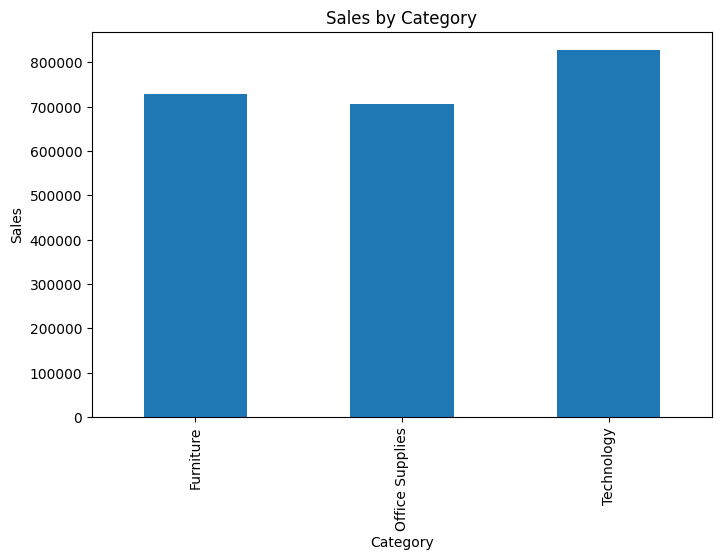

In [15]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

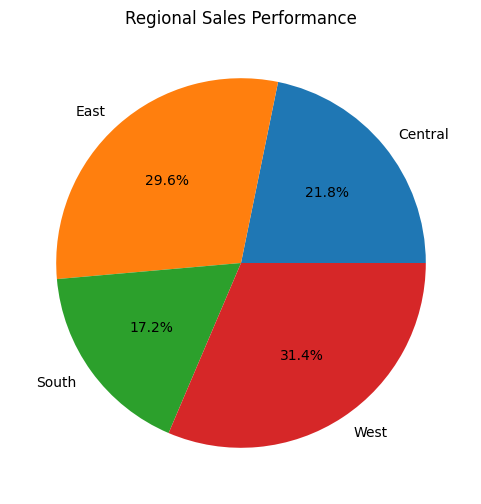

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Regional Sales Performance')
plt.ylabel('')
plt.show()

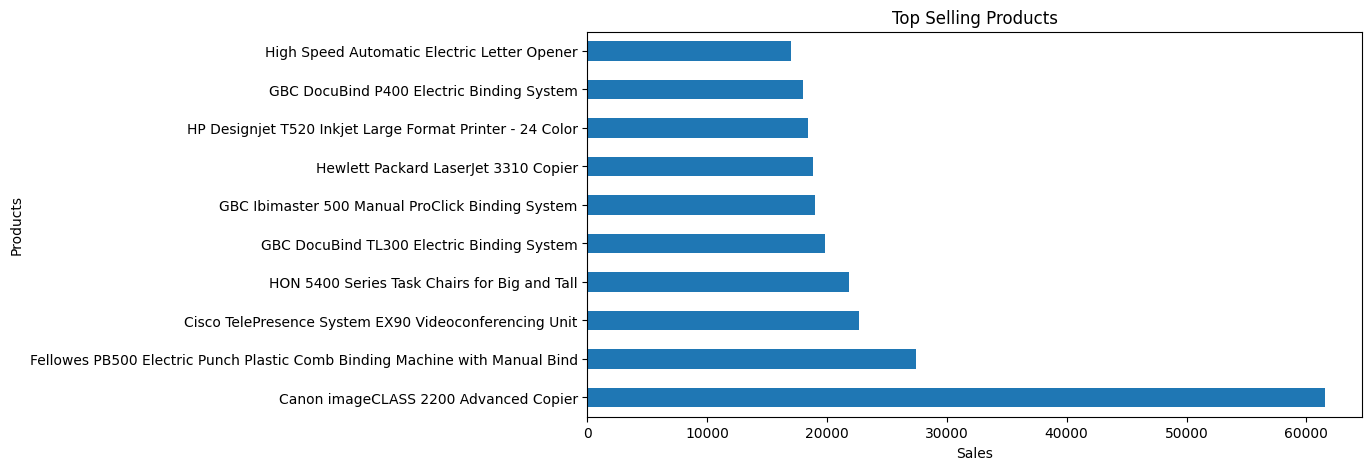

In [17]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(10,5))
plt.title('Top Selling Products')
plt.xlabel('Sales')
plt.ylabel('Products')
plt.show()

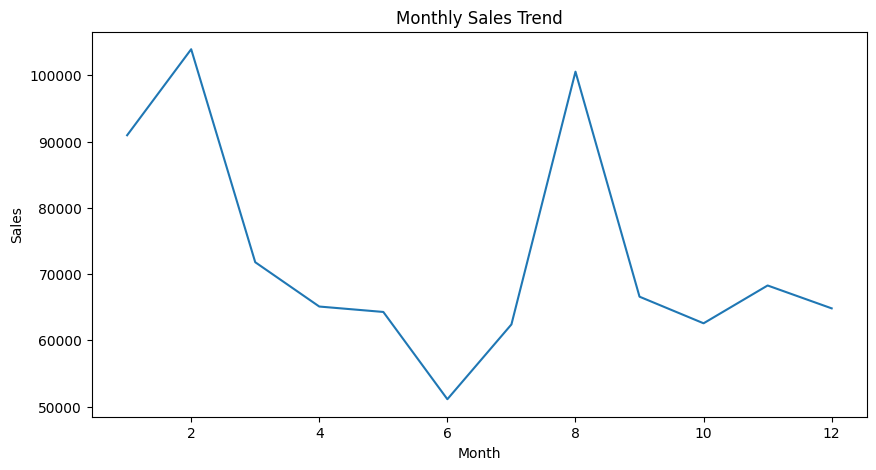

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
monthly_sales = df.groupby(df['Order_Date'].dt.month)['Sales'].sum()
monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

Insights

1. Technology category generated the highest sales.

2. West region showed better sales performance compared to other regions.

3. Top-selling products contributed significantly to total revenue.

4. Monthly sales trends showed variation in customer demand.

5. Data preprocessing improved analysis accuracy and dataset quality.

Conclusion

The sales performance analysis project helped identify important sales patterns, regional performance, and top-selling products using Python and visualization techniques. The analysis provided valuable business insights for improving sales strategies and decision-making.